In [13]:
import torch
import os
import re

In [14]:
def extract_info_from_intervention_log(model_dir, model_type="scbm", dataset="CUB", return_c_auroc=False, return_auroc=False):
    experiment_path = os.path.join("experiments", model_type, dataset)
    concepts_intervened_list = []
    y_accuracies_list = []
    c_accuracies_list = []
    y_auroc_list = []
    c_auroc_list = []

    with open(os.path.join(experiment_path, model_dir, "intervention_log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Intervention on" in line and "y_accuracy" in line and "c_accuracy" in line:
                m = re.search(r"Intervention on (\d+) concepts", line)
                if not m:
                    continue
                concepts_intervened = int(m.group(1))

                y_m = re.search(r"y_accuracy:\s*([0-9.]+)", line)
                c_m = re.search(r"c_accuracy:\s*([0-9.]+)", line)
                y_auroc_m = re.search(r"y_AUROC:\s*([0-9.]+)", line)
                c_auroc_m = re.search(r"c_AUROC:\s*([0-9.]+)", line)

                y_accuracy = float(y_m.group(1)) * 100 if y_m else None
                c_accuracy = float(c_m.group(1)) * 100 if c_m else None
                y_auroc = float(y_auroc_m.group(1)) * 100 if y_auroc_m else None
                c_auroc = float(c_auroc_m.group(1)) * 100 if c_auroc_m else None

                concepts_intervened_list.append(concepts_intervened)
                y_accuracies_list.append(y_accuracy)
                c_accuracies_list.append(c_accuracy)
                y_auroc_list.append(y_auroc)
                c_auroc_list.append(c_auroc)
    if return_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, y_auroc_list, c_auroc_list
    if return_c_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, c_auroc_list
    return concepts_intervened_list, y_accuracies_list, c_accuracies_list

In [15]:
scbm_model = "Mateo_025_2026-05-06_14-14-58_11bb4"

# All models have L_int_extension_loss_weight_1
res_scbm_50_residuals = "Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_1_2026-07-30_17-04-11_72f02"

res_scbm_20_residuals = "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-07-31_20-15-47_174e5"

res_scbm_5_residuals = "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-07-31_20-15-47_496cf"

cbm_model = "Mateo_025_2026-08-03_20-58-31_fe8e0"

cbm_res_model = "Mateo_025_2026-08-06_16-24-27_dd094"




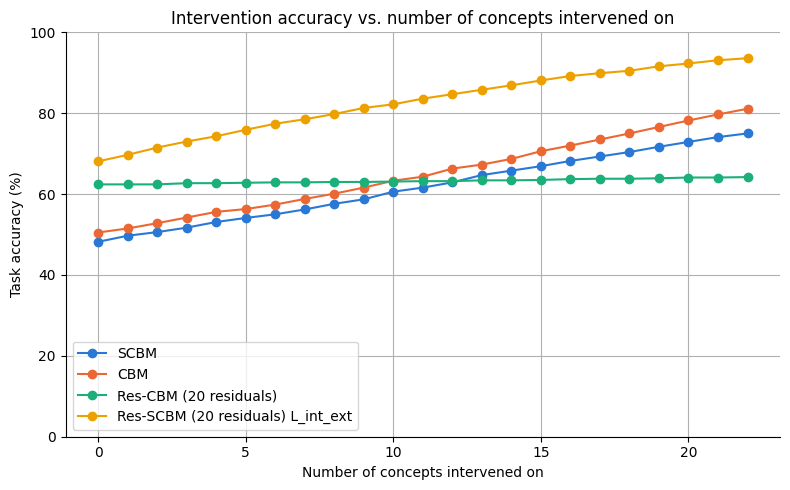

In [20]:
import matplotlib.pyplot as plt

# (label, model_dir, model_type) -- model_type selects the experiments/<model_type>/CUB/ subfolder
models = [
    ("SCBM", scbm_model, "scbm"),
    ("CBM", cbm_model, "cbm"),
    ("Res-CBM (20 residuals)", cbm_res_model, "cbm_residual"),
    #("Res-SCBM (50 residuals) L_int_ext", res_scbm_50_residuals, "scbm_residual"),
    ("Res-SCBM (20 residuals) L_int_ext", res_scbm_20_residuals, "scbm_residual"),
    #("Res-SCBM (5 residuals) L_int_ext", res_scbm_5_residuals, "scbm_residual"),
]
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9b59b6", "#e74c3c"]

fig, ax = plt.subplots(figsize=(8, 5))
for (label, model_dir, model_type), color in zip(models, colors):
    concepts_intervened, y_accuracies, c_accuracies = extract_info_from_intervention_log(
        model_dir, model_type=model_type, dataset="CUB"
    )
    ax.plot(concepts_intervened, y_accuracies, marker="o", color=color, label=label)

ax.set_xlabel("Number of concepts intervened on")
ax.set_ylabel("Task accuracy (%)")
ax.set_title("Intervention accuracy vs. number of concepts intervened on")
ax.legend()
ax.grid(True)
# y_max = 100
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
# Create dataframe for the results
import pandas as pd

# columns: model_name, num_concepts_intervened, y_accuracy, c_accuracy, y_auroc, c_auroc
# Only include 0, 11, and 22 concepts intervened
keep_concepts = {0, 11, 22}

rows = []
for label, model_dir, model_type in models:
    concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs = extract_info_from_intervention_log(
        model_dir, model_type=model_type, dataset="CUB", return_auroc=True
    )
    for n, y_acc, c_acc, y_auroc, c_auroc in zip(concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs):
        if n not in keep_concepts:
            continue
        rows.append({
            "model_name": label,
            "num_concepts_intervened": n,
            "y_accuracy": y_acc,
            "c_accuracy": c_acc,
            "y_auroc": y_auroc,
            "c_auroc": c_auroc,
        })

df = pd.DataFrame(rows, columns=["model_name", "num_concepts_intervened", "y_accuracy", "c_accuracy", "y_auroc", "c_auroc"])
df

,model_name,num_concepts_intervened,y_accuracy,c_accuracy,y_auroc,c_auroc
0,SCBM,0,48.2,94.5,96.8,97.0
1,SCBM,11,61.6,97.7,99.3,99.5
2,SCBM,22,75.0,100.0,99.8,100.0
3,CBM,0,50.5,94.2,96.7,96.8
4,CBM,11,64.3,97.1,99.3,99.2
5,CBM,22,81.1,100.0,99.9,100.0
6,Res-CBM (20 residuals),0,62.4,94.3,97.7,97.0
7,Res-CBM (20 residuals),11,63.2,97.2,97.9,99.2
8,Res-CBM (20 residuals),22,64.2,100.0,98.0,100.0
9,Res-SCBM (50 residuals) L_int_ext,0,68.2,94.7,98.8,97.4
